In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

keras.utils.set_random_seed(42)

In [ ]:
(x_train , y_train) , (x_test , y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
print(x_train.shape , y_train.shape)

(60000, 28, 28) (60000,)


In [ ]:
print(x_test.shape , y_test.shape)

(10000, 28, 28) (10000,)


In [ ]:
y_train[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

In [ ]:
labels = ["T-shirt/top",
          "Trouser",
          "Pullover",
          "Dress",
          "Coat",
          "Sandal",
          "Shirt",
          "Sneaker",
          "Bag",
          "Ankle boot"]

In [ ]:
labels[y_train[0]]

'Ankle boot'

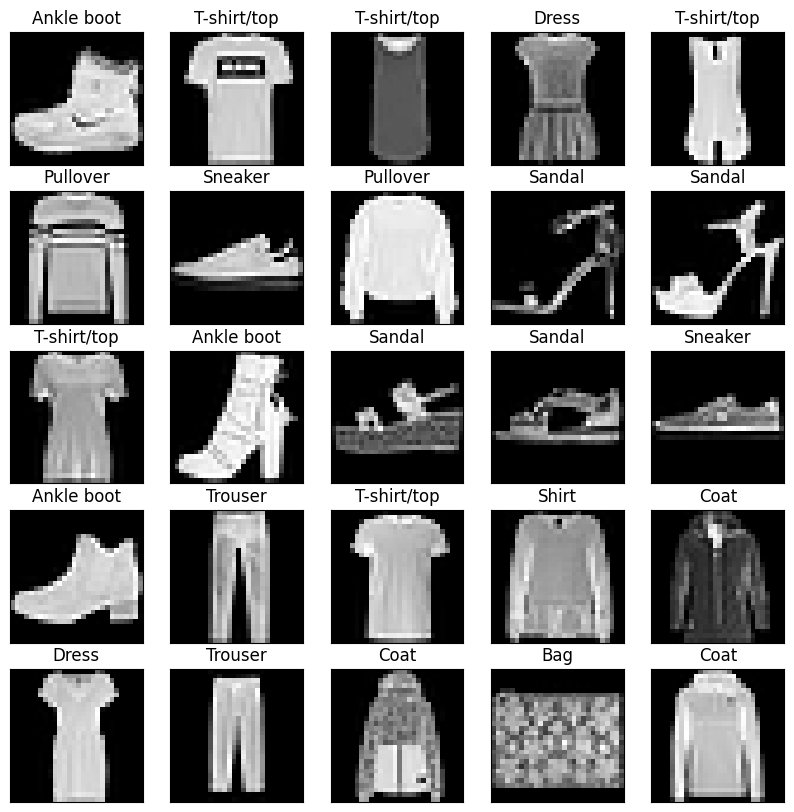

In [ ]:
fig , ax = plt.subplots(5,5,figsize=(10,10))
for i in range(25):
  axc = ax[i//5 , i%5]
  axc.imshow(x_train[i] , cmap="gray")
  axc.set_title(f"{labels[y_train[i]]}")
  axc.set_xticks([])
  axc.set_yticks([])

In [ ]:
def plot_loss_curves(history):
  plt.clf()
  history_dict = history.history
  loss_values = history_dict["loss"]
  val_loss_values = history_dict["val_loss"]
  epochs = range(1 , len(loss_values)+1)
  plt.plot(epochs , loss_values , "bo" , label="Training Loss")
  plt.plot(epochs , val_loss_values , "b" , label="Validation Loss")
  plt.title("Training and Validation Loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

In [ ]:
def plot_accuracy_curves(history):
  plt.clf()
  hstory_dict = history.history
  accuracy_values = hstory_dict["accuracy"]
  val_accuracy_values = hstory_dict["val_accuracy"]
  epochs = range(1 , len(accuracy_values)+1)
  plt.plot(epochs , accuracy_values , "bo" , label="Training Accuracy")
  plt.plot(epochs , val_accuracy_values , "b" , label="Validation Accuracy")
  plt.title("Training and Validation Accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

In [ ]:
#Convolution Layers

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

In [ ]:
x_train.shape

(60000, 28, 28, 1)

In [ ]:
#Define model


In [ ]:
from os import name
#input layer
input = keras.Input(shape=x_train.shape[1:])
#First Convolution

x = keras.layers.Conv2D(32 , kernel_size=(2,2), activation='relu', name = "Conv_1")(input)

#Pooling
x = keras.layers.MaxPooling2D()(x)

#Second Convolution
x = keras.layers.Conv2D(32 , kernel_size=(2,2), activation='relu', name = "Conv_2")(input)

#Pooling
x = keras.layers.MaxPooling2D()(x)


#Flatten Layer
x = keras.layers.Flatten()(x)
#Fully connected Relu Layer
x = keras.layers.Dense(256 , activation='relu')(x)

#Output Softmax Layer
output = keras.layers.Dense(10, activation='softmax')(x)

model = keras.Model(input , output)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 27, 27, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,384,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,434 (5.29 MB)

 Trainable params: 1,387,434 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

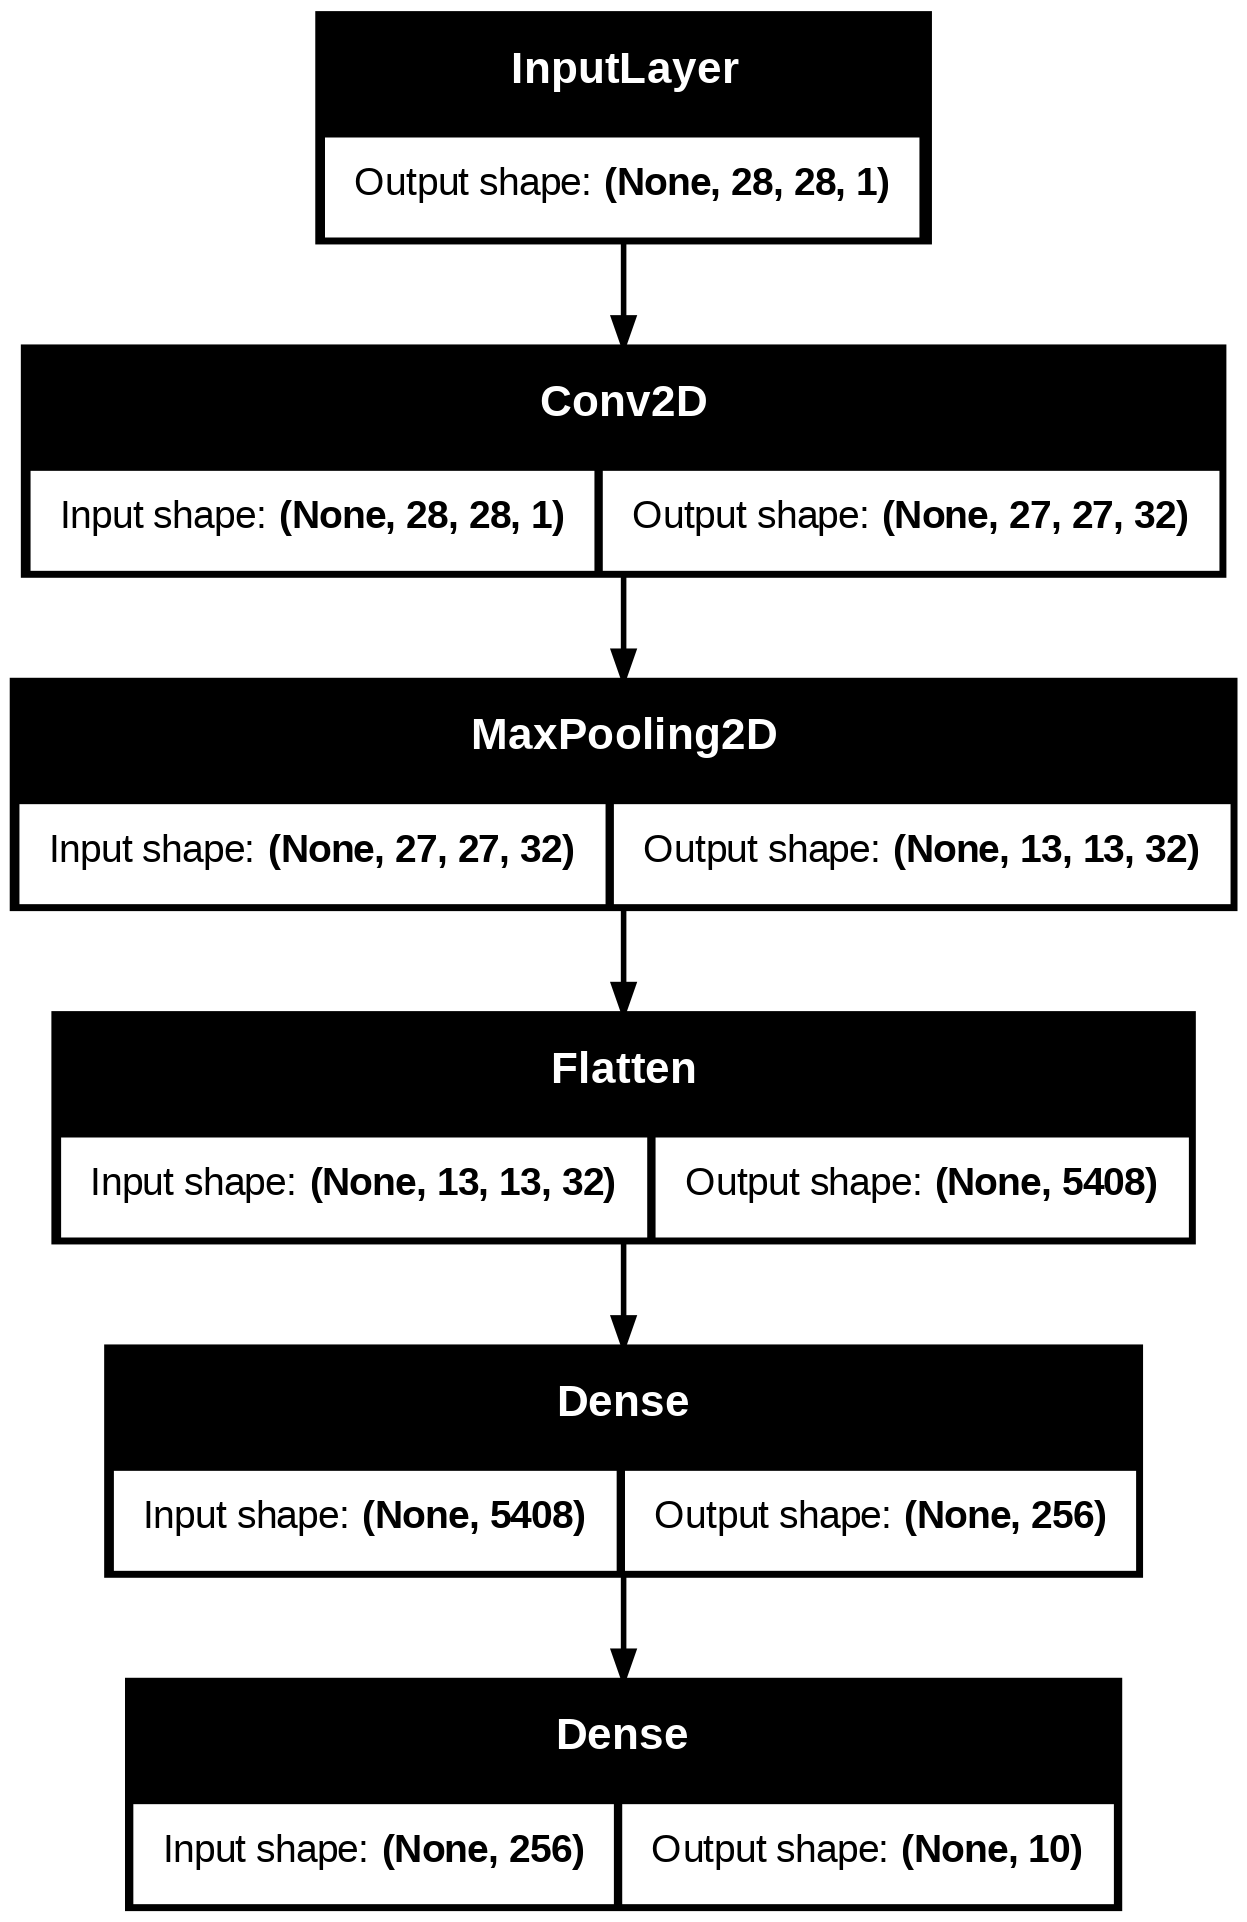

In [ ]:
keras.utils.plot_model(model , show_shapes=True)

In [ ]:
model.compile(loss = 'sparse_categorical_crossentropy',
              optimizer = 'adam',
              metrics = ['accuracy'])

In [ ]:
history = model.fit(x_train , y_train, batch_size=64, epochs=10, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.8403 - loss: 0.4486 - val_accuracy: 0.8781 - val_loss: 0.3466
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - accuracy: 0.8904 - loss: 0.3070 - val_accuracy: 0.8898 - val_loss: 0.3089
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 37s 49ms/step - accuracy: 0.9066 - loss: 0.2587 - val_accuracy: 0.8974 - val_loss: 0.2877
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.9185 - loss: 0.2244 - val_accuracy: 0.9001 - val_loss: 0.2775
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.9296 - loss: 0.1961 - val_accuracy: 0.9036 - val_loss: 0.2695
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.9392 - loss: 0.1712 - val_accuracy: 0.9043 - val_loss: 0.2705
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.9480 - loss: 0.1482 - val_accuracy: 0.9032 - val_loss: 0.2827
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.9561 - loss: 0.1279 - 

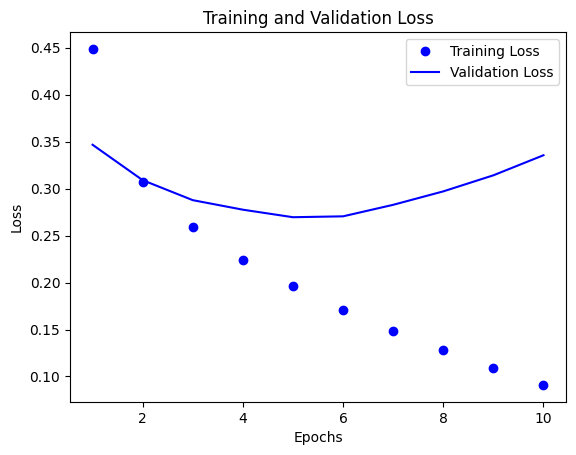

In [ ]:
plot_loss_curves(history)

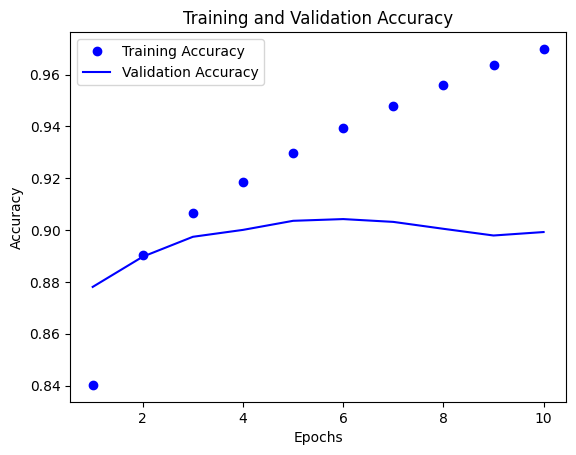

In [ ]:
plot_accuracy_curves(history)

In [ ]:
score = model.evaluate(x_test , y_test)
print("Test Accuracy" , score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8950 - loss: 0.3640
Test Accuracy 0.8949999809265137
